# 必要なライブラリの読み込み

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib
import matplotlib.pyplot as plt
import japanize_matplotlib

import sklearn
from sklearn.metrics import roc_curve,roc_auc_score
from sklearn.preprocessing import LabelEncoder
import optuna
from datetime import datetime
import os
import uuid
import pickle

import chainer
import chainer.functions as F
import chainer.links as L
from chainer import training
from chainer.training import extensions
from chainer import serializers

# データの読み込みと加工

## データの読み込み

In [2]:
targetDF = pd.read_pickle("../data/forModeling/forModelingDF.pickle")

In [3]:
pd.set_option('display.max_columns', targetDF.shape[1])
targetDF.head()

,枠番,馬番,斤量,単勝,人気,raceID,horseID,jockeyID,raceName,course_len,weather,raceType,groundState,date,Rank,Sex,Age,Weight,WeightVariation,pre1Rank,pre2Rank,pre3Rank,pre4Rank,pre5Rank,preAllRankMean,pre1Term,pre2Term,pre3Term,pre4Term,pre5Term
0,1,1,54,1.1,1,201801010101,2016104880,05339,2歳未勝利,1800,晴,芝,良,2018-07-28,1,牝,2,458,4,3.0,NaN,NaN,NaN,NaN,3.0,20.0,NaN,NaN,NaN,NaN
1,6,6,54,7.6,2,201801010101,2016101840,05203,2歳未勝利,1800,晴,芝,良,2018-07-28,2,牡,2,488,6,4.0,5.0,NaN,NaN,NaN,4.5,7.0,13.0,NaN,NaN,NaN
2,3,3,54,8.3,3,201801010101,2016105057,01127,2歳未勝利,1800,晴,芝,良,2018-07-28,3,牡,2,480,-6,5.0,NaN,NaN,NaN,NaN,5.0,13.0,NaN,NaN,NaN,NaN
3,4,4,54,46.7,5,201801010101,2016103985,01085,2歳未勝利,1800,晴,芝,良,2018-07-28,4,牡,2,460,-8,11.0,NaN,NaN,NaN,NaN,11.0,6.0,NaN,NaN,NaN,NaN
4,5,5,52,39.8,4,201801010101,2016103821,01170,2歳未勝利,1800,晴,芝,良,2018-07-28,5,牡,2,470,-8,7.0,NaN,NaN,NaN,NaN,7.0,13.0,NaN,NaN,NaN,NaN


In [4]:
targetDF["groundState"].unique()

array(['良', '不良', '稍重', '重'], dtype=object)

In [5]:
targetDF.isnull().any()

枠番                 False
馬番                 False
斤量                 False
単勝                 False
人気                 False
raceID             False
horseID            False
jockeyID           False
raceName           False
course_len         False
weather            False
raceType           False
groundState        False
date               False
Rank               False
Sex                False
Age                False
Weight             False
WeightVariation    False
pre1Rank            True
pre2Rank            True
pre3Rank            True
pre4Rank            True
pre5Rank            True
preAllRankMean      True
pre1Term            True
pre2Term            True
pre3Term            True
pre4Term            True
pre5Term            True
dtype: bool

In [6]:
targetDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308474 entries, 0 to 308473
Data columns (total 30 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   枠番               308474 non-null  int32         
 1   馬番               308474 non-null  int32         
 2   斤量               308474 non-null  int32         
 3   単勝               308474 non-null  float64       
 4   人気               308474 non-null  int32         
 5   raceID           308474 non-null  object        
 6   horseID          308474 non-null  object        
 7   jockeyID         308474 non-null  object        
 8   raceName         308474 non-null  object        
 9   course_len       308474 non-null  int32         
 10  weather          308474 non-null  object        
 11  raceType         308474 non-null  object        
 12  groundState      308474 non-null  object        
 13  date             308474 non-null  datetime64[ns]
 14  Rank             308

## データの加工

In [7]:
categorical_features = ["weather","raceType","groundState","Sex"]

In [8]:
def dataProcessing(df:pd.DataFrame):
    returnDF = df.copy()

    #新馬戦/未勝利戦の除外(やるかどうか検討中)
    #returnDF = returnDF[returnDF["raceName"].str.contains(("新馬")) == False]
    #returnDF = returnDF[returnDF["raceName"].str.contains(("未勝利")) == False]

    #raceIDをデータフレームのインデックスとして設定
    returnDF.set_index("raceID",inplace=True)
    returnDF.index.name = None

    #目的変数の作成:3着以内かどうかの二値分類に帰着させる
    returnDF["y"] = returnDF["Rank"].map(lambda x:1 if x < 4 else 0)

    #不要なカラムの削除
    #returnDF.drop(columns = ["horseID","jockeyID","raceName","Rank","date","人気","単勝"],inplace = True)
    returnDF.drop(columns = ["horseID","jockeyID","raceName","Rank","date"],inplace = True)

    for col in categorical_features:
        LE = LabelEncoder()
        LE.fit(returnDF[col])
        #LE.classes_ = np.append(LE.classes_,"該当なし")
        with open(f"../data/labelencoder/{col}_labelEncoder.pickle","wb") as f:
            pickle.dump(LE,f)

        returnDF[col] = LE.transform(returnDF[col])
        returnDF[col] = returnDF[col].astype("category")

    returnDF["weather"]=returnDF["weather"].astype("category")
    returnDF["raceType"]=returnDF["raceType"].astype("category")
    returnDF["groundState"]=returnDF["groundState"].astype("category")
    returnDF["Sex"]=returnDF["Sex"].astype("category")

    #欠損値を-1で補完
    returnDF = returnDF.fillna({
        "pre1Rank":-1,
        "pre2Rank":-1,
        "pre3Rank":-1,
        "pre4Rank":-1,
        "pre5Rank":-1,
        "preAllRankMean":-1,
        "pre1Term":-1,
        "pre2Term":-1,
        "pre3Term":-1,
        "pre4Term":-1,
        "pre5Term":-1})

    return returnDF

In [9]:
targetdfFin = dataProcessing(targetDF)

In [10]:
targetdfFin.info()

<class 'pandas.core.frame.DataFrame'>
Index: 308474 entries, 201801010101 to 202410030812
Data columns (total 25 columns):
 #   Column           Non-Null Count   Dtype   
---  ------           --------------   -----   
 0   枠番               308474 non-null  int32   
 1   馬番               308474 non-null  int32   
 2   斤量               308474 non-null  int32   
 3   単勝               308474 non-null  float64 
 4   人気               308474 non-null  int32   
 5   course_len       308474 non-null  int32   
 6   weather          308474 non-null  category
 7   raceType         308474 non-null  category
 8   groundState      308474 non-null  category
 9   Sex              308474 non-null  category
 10  Age              308474 non-null  int32   
 11  Weight           308474 non-null  int32   
 12  WeightVariation  308474 non-null  int32   
 13  pre1Rank         308474 non-null  float64 
 14  pre2Rank         308474 non-null  float64 
 15  pre3Rank         308474 non-null  float64 
 16  pre4Rank

In [11]:
targetdfFin.columns

Index(['枠番', '馬番', '斤量', '単勝', '人気', 'course_len', 'weather', 'raceType',
       'groundState', 'Sex', 'Age', 'Weight', 'WeightVariation', 'pre1Rank',
       'pre2Rank', 'pre3Rank', 'pre4Rank', 'pre5Rank', 'preAllRankMean',
       'pre1Term', 'pre2Term', 'pre3Term', 'pre4Term', 'pre5Term', 'y'],
      dtype='object')

In [12]:
targetdfFin.isnull().any()

枠番                 False
馬番                 False
斤量                 False
単勝                 False
人気                 False
course_len         False
weather            False
raceType           False
groundState        False
Sex                False
Age                False
Weight             False
WeightVariation    False
pre1Rank           False
pre2Rank           False
pre3Rank           False
pre4Rank           False
pre5Rank           False
preAllRankMean     False
pre1Term           False
pre2Term           False
pre3Term           False
pre4Term           False
pre5Term           False
y                  False
dtype: bool

In [13]:
targetdfFin.head()

,枠番,馬番,斤量,単勝,人気,course_len,weather,raceType,groundState,Sex,Age,Weight,WeightVariation,pre1Rank,pre2Rank,pre3Rank,pre4Rank,pre5Rank,preAllRankMean,pre1Term,pre2Term,pre3Term,pre4Term,pre5Term,y
201801010101,1,1,54,1.1,1,1800,2,1,2,1,2,458,4,3.0,-1.0,-1.0,-1.0,-1.0,3.0,20.0,-1.0,-1.0,-1.0,-1.0,1
201801010101,6,6,54,7.6,2,1800,2,1,2,2,2,488,6,4.0,5.0,-1.0,-1.0,-1.0,4.5,7.0,13.0,-1.0,-1.0,-1.0,1
201801010101,3,3,54,8.3,3,1800,2,1,2,2,2,480,-6,5.0,-1.0,-1.0,-1.0,-1.0,5.0,13.0,-1.0,-1.0,-1.0,-1.0,1
201801010101,4,4,54,46.7,5,1800,2,1,2,2,2,460,-8,11.0,-1.0,-1.0,-1.0,-1.0,11.0,6.0,-1.0,-1.0,-1.0,-1.0,0
201801010101,5,5,52,39.8,4,1800,2,1,2,2,2,470,-8,7.0,-1.0,-1.0,-1.0,-1.0,7.0,13.0,-1.0,-1.0,-1.0,-1.0,0


# モデリング

## データをtrain,valid,testに分割

In [14]:
trainYearlist = ("2019","2020","2021","2022")
validYearList = ("2023")
testYearList = ("2024")

In [15]:
trainDF = targetdfFin[targetdfFin.index.str.startswith(trainYearlist)]
validDF = targetdfFin[targetdfFin.index.str.startswith(validYearList)]
testDF = targetdfFin[targetdfFin.index.str.startswith(testYearList)]

In [16]:
trainDF

,枠番,馬番,斤量,単勝,人気,course_len,weather,raceType,groundState,Sex,Age,Weight,WeightVariation,pre1Rank,pre2Rank,pre3Rank,pre4Rank,pre5Rank,preAllRankMean,pre1Term,pre2Term,pre3Term,pre4Term,pre5Term,y
201901010101,1,1,54,1.4,1,1800,3,1,2,2,2,518,-16,3.0,-1.0,-1.0,-1.0,-1.0,3.000000,48.0,-1.0,-1.0,-1.0,-1.0,1
201901010101,3,3,54,3.5,2,1800,3,1,2,2,2,496,-8,2.0,-1.0,-1.0,-1.0,-1.0,2.000000,13.0,-1.0,-1.0,-1.0,-1.0,1
201901010101,4,4,51,46.6,6,1800,3,1,2,2,2,546,6,10.0,-1.0,-1.0,-1.0,-1.0,10.000000,42.0,-1.0,-1.0,-1.0,-1.0,1
201901010101,8,9,51,56.8,7,1800,3,1,2,2,2,458,-8,4.0,-1.0,-1.0,-1.0,-1.0,4.000000,13.0,-1.0,-1.0,-1.0,-1.0,0
201901010101,5,5,54,140.3,9,1800,3,1,2,2,2,436,0,9.0,-1.0,-1.0,-1.0,-1.0,9.000000,20.0,-1.0,-1.0,-1.0,-1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202210040812,6,11,57,29.7,9,2600,2,1,2,2,4,476,-12,7.0,4.0,-1.0,-1.0,-1.0,5.500000,43.0,538.0,-1.0,-1.0,-1.0,0
202210040812,3,5,49,139.1,15,2600,2,1,2,1,3,444,6,6.0,8.0,4.0,7.0,11.0,9.428571,14.0,22.0,91.0,14.0,118.0,0
202210040812,4,6,52,82.7,13,2600,2,1,2,0,3,502,10,10.0,6.0,1.0,6.0,-1.0,5.750000,113.0,21.0,98.0,27.0,-1.0,0
202210040812,7,13,54,7.2,5,2600,2,1,2,2,3,524,2,1.0,3.0,3.0,7.0,-1.0,3.500000,119.0,105.0,15.0,14.0,-1.0,0


In [17]:
trainDF_x = trainDF.drop(["y"], axis = 1)
trainDF_y = trainDF["y"]

validDF_x = validDF.drop(["y"], axis = 1)
validDF_y = validDF["y"]

testDF_x = testDF.drop(["y"], axis = 1)
testDF_y = testDF["y"]

## LGBM

### モデリング

In [ ]:
lgb_train = lgb.Dataset(trainDF_x, trainDF_y, categorical_feature=["weather","raceType","groundState","Sex"])
lgb_valid = lgb.Dataset(validDF_x, validDF_y)

lgbm_params = {
        'boosting_type': 'gbdt',
        'objective': 'binary',
        'metric': 'auc',
        #'num_leaves': 500,
        'max_depth:': 10,
        'min_data_in_leaf': 50,
        'learning_rate': 0.02,
        'feature_traction':0.6,
        'verbose' : -1
}

results = {}
val_err = 0

modelLGBM = lgb.train(
    lgbm_params, 
    lgb_train, 
    valid_sets=(lgb_train, lgb_valid), 
    valid_names=['train', 'valid'],
    num_boost_round=10000, 
    callbacks=[
        lgb.early_stopping(1000, False, True),
        lgb.record_evaluation(results),
        lgb.log_evaluation(period=250)
    ]
)

Training until validation scores don't improve for 1000 rounds
[250]	train's auc: 0.820366	valid's auc: 0.816196
[500]	train's auc: 0.826818	valid's auc: 0.816065
[750]	train's auc: 0.832929	valid's auc: 0.815912
[1000]	train's auc: 0.838597	valid's auc: 0.815723
[1250]	train's auc: 0.844	valid's auc: 0.815433
Early stopping, best iteration is:
[352]	train's auc: 0.823093	valid's auc: 0.816258


### モデルの保存

In [ ]:
modelIDLGBM = 1
with open(f"../models/LightGBM/LGBM_{modelIDLGBM}.pickle", "wb") as f:
    pickle.dump(modelLGBM, f)

### 精度確認

train's AUC:0.8230929677936065
valid's AUC :0.8162577848089879
test's AUC :0.8232352605540314


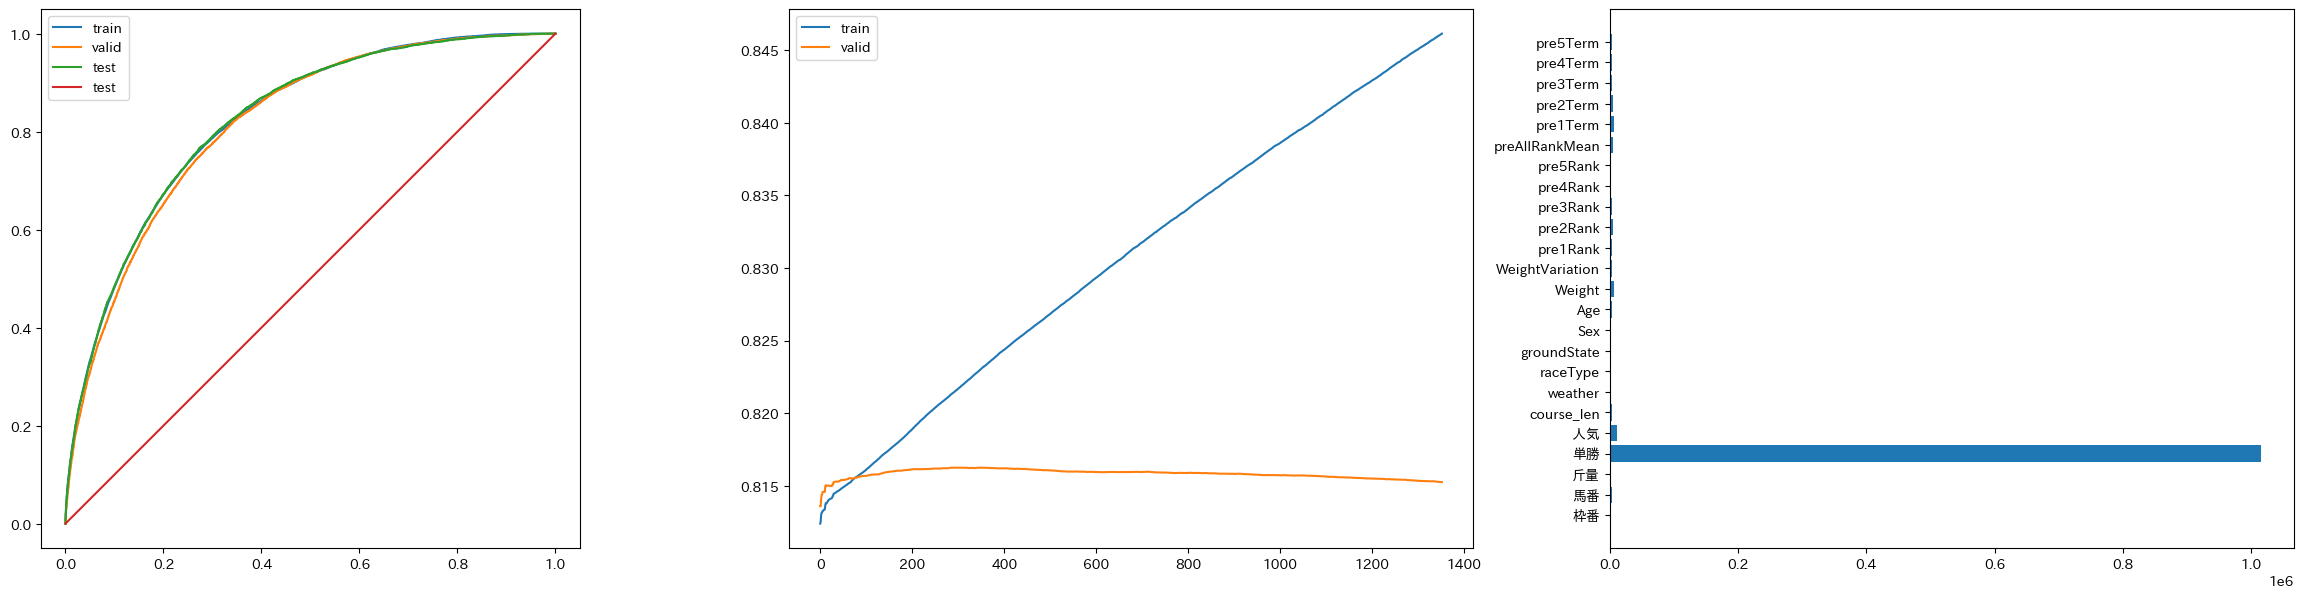

In [21]:
predTrian = modelLGBM.predict(trainDF_x)
predValid = modelLGBM.predict(validDF_x)
predTest = modelLGBM.predict(testDF_x)

print(f"train's AUC:{roc_auc_score(trainDF_y,predTrian)}")
print(f"valid's AUC :{roc_auc_score(validDF_y,predValid)}")
print(f"test's AUC :{roc_auc_score(testDF_y,predTest)}")

trainfpr, traintpr, trainthresholds = roc_curve(trainDF_y,predTrian)
validfpr, validtpr, validthresholds = roc_curve(validDF_y,predValid)
testfpr , testtpr , testthresholds  = roc_curve(testDF_y,predTest)

fig, axs = plt.subplots(ncols=3, figsize=[30, 7])

axs[0].plot(trainfpr, traintpr,label="train")
axs[0].plot(validfpr, validtpr,label="valid")
axs[0].plot(testfpr, testtpr,label="test")
axs[0].plot(testfpr, testfpr,label="test")
axs[0].set_aspect("equal")
axs[0].legend()

axs[1].plot(results["train"]["auc"],label="train")
axs[1].plot(results["valid"]["auc"],label="valid")
axs[1].legend()

importance = pd.DataFrame(modelLGBM.feature_importance(importance_type='gain'), index=trainDF_x.columns,columns=['importance'])
axs[2].barh(importance.index,importance["importance"])
plt.show()

## DNN

### 前処理

In [23]:
#numpyの形式に変換
train_x = trainDF_x.values
train_y = trainDF_y.values

valid_x = validDF_x.values
valid_y = validDF_y.values

test_x = testDF_x.values
test_y = testDF_y.values

#32bitに変換
train_x = train_x.astype(np.float32)
train_y = train_y.astype(np.int32)

valid_x = valid_x.astype(np.float32)
valid_y = valid_y.astype(np.int32)

test_x = test_x.astype(np.float32)
test_y = test_y.astype(np.int32)

print(f"train_x:{train_x.dtype}")
print(f"train_y:{train_y.dtype}")

print(f"valid_x:{valid_x.dtype}")
print(f"valid_y:{valid_y.dtype}")

print(f"test_x:{test_x.dtype}")
print(f"test_y:{test_y.dtype}")

train_x:float32
train_y:int32
valid_x:float32
valid_y:int32
test_x:float32
test_y:int32


In [24]:
trainDataset = chainer.datasets.TupleDataset(train_x,train_y)
validDataset = chainer.datasets.TupleDataset(valid_x,valid_y)
testDataset = chainer.datasets.TupleDataset(test_x,test_y)

In [30]:
train_x.shape

(174634, 24)

### モデリング

#### ネットワークの形式を定義

In [33]:
class Mychain(chainer.Chain):
    def __init__(self):
        super().__init__(
            bn = L.BatchNormalization(24),
            l1 = L.Linear(None, 24),
            l2 = L.Linear(None, 12),
            l3 = L.Linear(None, 6),
            l4 = L.Linear(None, 2),
        )

    def __call__(self,x):
        h1 = F.relu(self.l1(self.bn(x)))
        h2 = F.relu(self.l2(h1))
        h3 = F.relu(self.l3(h2))
        output = self.l4(h3)

        return output

In [34]:
# モデルのインスタンス化
modelNN = L.Classifier(Mychain(),lossfun=F.softmax_cross_entropy,accfun=F.accuracy)

optimizer = chainer.optimizers.Adam(alpha=0.001)
optimizer.setup(modelNN)

batchsize = 500
train_iter = chainer.iterators.SerialIterator(trainDataset, batchsize)
test_iter = chainer.iterators.SerialIterator(validDataset, batchsize, repeat=False, shuffle=False)

epoch=100
updater = chainer.training.StandardUpdater(train_iter, optimizer,device=-1)

trainer = chainer.training.Trainer(updater, (epoch, 'epoch'), out="output/logs")
trainer.extend(chainer.training.extensions.Evaluator(test_iter, modelNN,device=-1))
log_report_extension = chainer.training.extensions.LogReport(trigger=(1,"epoch"),log_name="log")
trainer.extend(chainer.training.extensions.PrintReport(['epoch', 'main/accuracy', 'validation/main/accuracy', 'main/loss', 'validation/main/loss', 'elapsed_time']),trigger=(1,"epoch"))
trainer.extend(log_report_extension)

trainer.run()


epoch       main/accuracy  validation/main/accuracy  main/loss   validation/main/loss  elapsed_time
1           0.785417       0.79469                   0.451815    0.423858              1.57986       
2           0.800533       0.801168                  0.422022    0.418188              3.12745       
3           0.804143       0.802826                  0.418526    0.416493              4.64724       
4           0.804891       0.803771                  0.416849    0.41575               6.16784       
5           0.806          0.80261                   0.415706    0.415105              7.67422       
6           0.805966       0.802887                  0.415182    0.415165              9.20004       
7           0.806504       0.803995                  0.414815    0.414889              10.7036       
8           0.806137       0.804017                  0.414715    0.414904              12.2456       
9           0.807152       0.803678                  0.41424     0.414744           

In [35]:
modelIDNN = 1
chainer.serializers.save_npz(f"../models/neuralNetwork/NN_{modelIDNN}.npz",modelNN)

train's AUC:0.8126988834842017
valid's AUC :0.8150932635464643
test's AUC :0.8221094438371259


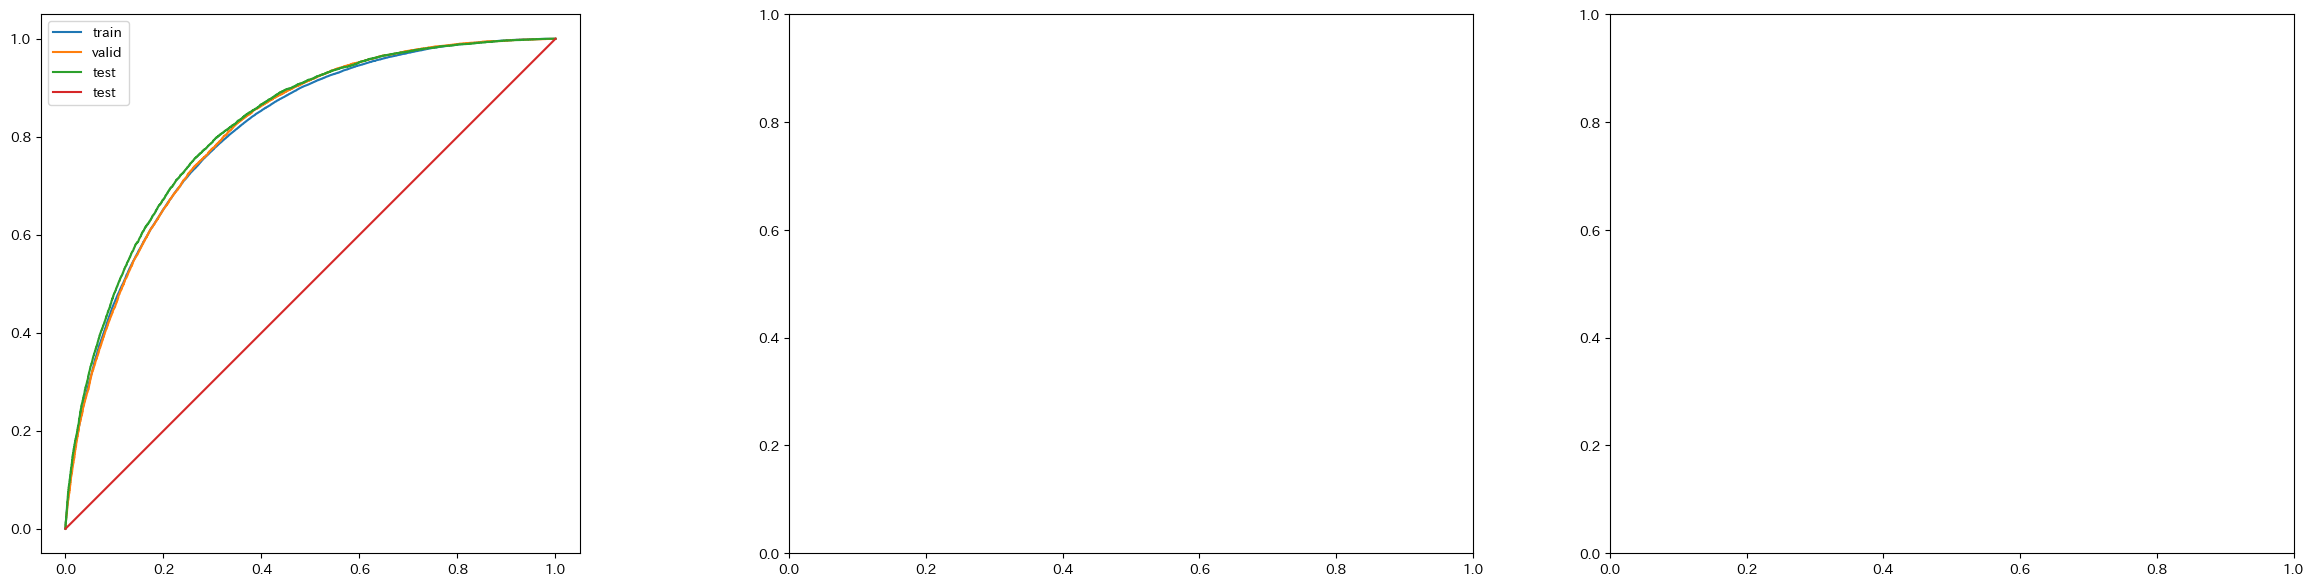

In [22]:
predTrainNN = F.softmax(modelNN.predictor(train_x)).data[:,1]
predValidNN = F.softmax(modelNN.predictor(valid_x)).data[:,1]
predTestNN  = F.softmax(modelNN.predictor(test_x)).data[:,1]

print(f"train's AUC:{roc_auc_score(train_y,predTrainNN)}")
print(f"valid's AUC :{roc_auc_score(validDF_y,predValidNN)}")
print(f"test's AUC :{roc_auc_score(testDF_y,predTestNN)}")

trainfpr, traintpr, trainthresholds = roc_curve(train_y,predTrainNN)
validfpr, validtpr, validthresholds = roc_curve(valid_y,predValidNN)
testfpr , testtpr , testthresholds  = roc_curve(test_y,predTestNN)

fig, axs = plt.subplots(ncols=3, figsize=[30, 7])

axs[0].plot(trainfpr, traintpr,label="train")
axs[0].plot(validfpr, validtpr,label="valid")
axs[0].plot(testfpr, testtpr,label="test")
axs[0].plot(testfpr, testfpr,label="test")
axs[0].set_aspect("equal")
axs[0].legend()